<a href="https://colab.research.google.com/github/Yuliia-Safonova/DTA-2026/blob/main/ML/ml_practice_LR%26Cl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практика: лінійна регресія та класифікація

Це тренувальний блокнот для закріплення базового циклу ML. Завдання **нескладні** й повторюють кроки з основного тьюторіалу — тільки тепер усе робиш **сам**.

**Дві задачі на двох нових наборах даних:**
- **Задача A (регресія):** передбачити **зарплату** працівника.
- **Задача B (класифікація):** передбачити, чи **складе студент іспит** (так/ні).

**Як працювати:**
1. Запусти комірку «Підготовка даних» нижче — вона все налаштує.
2. Іди по кроках. Там, де стоїть `# TODO`, — впиши свій код.
3. Підказки є під кожним кроком.

> 💡 Усі потрібні інструменти ти вже бачив: `train_test_split`, `LinearRegression`, `DecisionTreeClassifier`, `.fit()`, `.predict()`, метрики. Тримай той блокнот поруч як шпаргалку.

---

## 🔧 Підготовка даних (просто запусти)

In [109]:
# ▶️ Просто запусти цю комірку — вона готує дані. Міняти нічого не треба.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 20)

# ---------- Дані A: ЗАРПЛАТИ (для регресії) ----------
N = 800
experience = np.random.randint(0, 31, N)                      # стаж, років
age        = (22 + experience + np.random.randint(0, 12, N)).clip(22, 64)  # вік
education  = np.random.choice([12, 15, 16, 18, 20], N,        # років освіти
                              p=[.2, .15, .35, .2, .1])
english    = np.random.randint(1, 6, N)                       # рівень англ. 1..5

salary = (8000                       # базова ставка, грн
          + experience * 900         # за кожен рік стажу
          + education  * 600         # за рік освіти
          + english    * 1500        # за рівень англійської
          + np.random.normal(0, 3000, N)   # шум: усе інше
         ).clip(8000, None)

salary_df = pd.DataFrame({
    "experience": experience, "age": age,
    "education": education, "english": english,
    "salary": salary.round(0).astype(int),
})

# ---------- Дані B: СТУДЕНТИ (для класифікації) ----------
M = 800
study     = np.random.normal(12, 5, M).clip(0, 30)            # годин навчання/тиждень
attendance= np.random.normal(78, 15, M).clip(30, 100)        # відвідуваність, %
prev_score= np.random.normal(65, 18, M).clip(0, 100)         # бал за минулий іспит
sleep     = np.random.normal(7, 1.2, M).clip(4, 10)          # годин сну

score_logit = (0.12*study + 0.04*attendance + 0.05*prev_score
               + 0.3*sleep - 9 + np.random.normal(0, 1.2, M))
passed = (score_logit > 0).astype(int)                        # 1 = склав, 0 = ні

students_df = pd.DataFrame({
    "study": study.round(1), "attendance": attendance.round(0).astype(int),
    "prev_score": prev_score.round(0).astype(int), "sleep": sleep.round(1),
    "passed": passed,
})

print("✅ Дані готові.")
print("Зарплати:", salary_df.shape, "| Студенти:", students_df.shape)
print("Частка тих, хто склав іспит:", f"{students_df['passed'].mean():.0%}")

✅ Дані готові.
Зарплати: (800, 5) | Студенти: (800, 5)
Частка тих, хто склав іспит: 69%


---
# 🟦 Задача A. Регресія: передбачаємо зарплату

Дані у таблиці `salary_df`. Ознаки: `experience` (стаж), `age` (вік), `education` (років освіти), `english` (рівень англійської 1–5). Ціль: `salary` (зарплата, грн).

Мета — навчити модель передбачати зарплату і **пояснити**, що на неї впливає.

### Крок A1. Подивись на дані
Виведи перші рядки таблиці й описову статистику. Це звичка №1 перед будь-яким навчанням.

*Підказка:* `salary_df.head()` і `salary_df.describe()`.

In [110]:
# TODO: виведи перші рядки salary_df
display(salary_df.head())

# TODO: виведи describe()
display(salary_df.describe().round(2))

,experience,age,education,english,salary
0,6,32,15,2,23714
1,19,44,12,3,32814
2,28,54,12,5,54472
3,14,42,20,5,35964
4,10,40,18,2,29723


,experience,age,education,english,salary
count,800.00,800.00,800.00,800.00,800.00
mean,15.42,42.75,15.86,3.03,36028.93
std,9.33,9.92,2.41,1.43,9242.04
min,0.00,22.00,12.00,1.00,12917.00
25%,7.00,35.00,15.00,2.00,28550.75
50%,16.00,43.00,16.00,3.00,36102.50
75%,24.00,51.00,18.00,4.00,43545.50
max,30.00,62.00,20.00,5.00,55947.00


### Крок A2. Признач ознаки (X) і ціль (y), поділи на train / test
- `X` — усі стовпці, КРІМ `salary`.
- `y` — стовпець `salary`.
- Поділ: 20% у тест, `random_state=RANDOM_STATE`.

*Підказка:* `X = salary_df[["experience", "age", "education", "english"]]`,
`y = salary_df["salary"]`, далі `train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)`.

In [111]:
from sklearn.model_selection import train_test_split

# TODO: створи X та y
X = salary_df[['experience', 'age', 'education', 'english']]
y = salary_df['salary']

# TODO: поділи на X_train, X_test, y_train, y_test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

# print("Train:", X_train.shape[0], "| Test:", X_test.shape[0])
print(f"Навчальна вибірка: {X_train.shape[0]} співробітників")
print(f"Тестова вибірка: {X_test.shape[0]} співробітників")

Навчальна вибірка: 640 співробітників
Тестова вибірка: 160 співробітників


### Крок A3. Навчи лінійну регресію
Згадай цикл: **створити → `.fit(X_train, y_train)`**.

*Підказка:* `from sklearn.linear_model import LinearRegression`, далі `model = LinearRegression()` і `model.fit(...)`.

In [112]:
from sklearn.linear_model import LinearRegression

# TODO: створи та навчи модель
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

### Крок A4. Зроби передбачення й оціни якість
- Передбач на `X_test`.
- Порахуй **MAE** та **R²**.

*Підказка:* `y_pred = model.predict(X_test)`; `mean_absolute_error(y_test, y_pred)`;
`r2_score(y_test, y_pred)`.

In [113]:
from sklearn.metrics import mean_absolute_error, r2_score

# TODO: передбач y_pred
y_pred = model.predict(X_test)

compare = pd.DataFrame({
        'real_salary': y_test[:5].round(2),
        'predict_salary': y_pred[:5].round(2)
})
compare['error'] = (compare['predict_salary'] - compare['real_salary']).round(2)
compare

# TODO: порахуй і виведи MAE та R²
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MAE = {mae:.1f} грн (середня помилка)')
print(f'R² = {r2:.3f} (модель пояснює {r2 * 100:.1f}% розкиду ціни)')

MAE = 2545.3 грн (середня помилка)
R² = 0.881 (модель пояснює 88.1% розкиду ціни)


### Крок A5. 🔑 Інтерпретуй коефіцієнти
Дістань коефіцієнти моделі й скажи словами, яка ознака найсильніше підвищує зарплату.

*Підказка:* `model.coef_` і `model.intercept_`. Зістав назви з `X.columns`.

In [114]:
# TODO: побудуй таблицю "ознака — коефіцієнт" і відсортуй
coefs = pd.DataFrame({
    'features': X.columns,
    'coef': model.coef_.round(2)
}).sort_values('coef', key=abs, ascending=False)

print(f'Базова зарплата: {model.intercept_:.2f} грн\n')
print('Як кожна ознака впливає на ціну')
coefs

Базова зарплата: 6850.03 грн

Як кожна ознака впливає на ціну


,features,coef
3,english,1597.45
0,experience,872.48
2,education,609.59
1,age,31.15


✍️ **Запиши відповідь словами** (просто текстом у цій комірці, подвійний клік):
> Найсильніше на зарплату впливає ознака english, бо її коефіцієнт є найбільшим (1597.45). Це означає, що зі збільшенням рівня англійської на 1 пункт зарплата в середньому зростає приблизно на 1597 грн за інших незмінних умов.

### Крок A6. Передбач зарплату для нового працівника
Створи одного працівника й передбач його зарплату: стаж 5, вік 30, освіта 16, англійська 4.

*Підказка:* зроби `pd.DataFrame([{...}])` з тими самими назвами стовпців і передай у `model.predict(...)`.

In [115]:
# TODO: створи new_employee і передбач зарплату
new_employee = pd.DataFrame([{
    'experience': 5,
    'age': 30,
    'education': 16,
    'english': 4
}])

display(new_employee)

print(f"\nЗарплата для даного працівника складатиме: {model.predict(new_employee)[0]:.1f} грн ± {mae:.1f} грн")

,experience,age,education,english
0,5,30,16,4



Зарплата для даного працівника складатиме: 28290.2 грн ± 2545.3 грн


---
# 🟩 Задача B. Класифікація: чи складе студент іспит

Дані у таблиці `students_df`. Ознаки: `study` (годин навчання/тиждень), `attendance` (відвідуваність %), `prev_score` (бал за минулий іспит), `sleep` (годин сну). Ціль: `passed` (1 = склав, 0 = ні).

### Крок B1. Подивись на дані
Виведи перші рядки й перевір баланс класів: яка частка студентів склала іспит?

*Підказка:* `students_df.head()` і `students_df["passed"].mean()`.

In [116]:
# TODO: head() і частка тих, хто склав
display(students_df.head())

print("\nЧастка студентів, яка склала іспит:", f"{students_df['passed'].mean():.1%}")

,study,attendance,prev_score,sleep,passed
0,11.2,76,94,5.7,1
1,18.5,72,49,9.4,1
2,15.7,71,59,7.9,0
3,16.1,100,88,5.1,1
4,9.9,92,72,7.0,1



Частка студентів, яка склала іспит: 69.4%


### Крок B2. X, y і поділ на train / test
- `X` — усе, крім `passed`. `y` — `passed`.
- Додай `stratify=y`, щоб пропорція класів збереглася.

*Підказка:* `train_test_split(Xs, ys, test_size=0.2, random_state=RANDOM_STATE, stratify=ys)`.

In [117]:
# TODO: Xs, ys та поділ на Xs_train, Xs_test, ys_train, ys_test
Xs = students_df[['study', 'attendance', 'prev_score', 'sleep']]
ys = students_df['passed']

Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    Xs, ys,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=ys
)

print('Навчальна вибірка:', Xs_train.shape[0], 'студентів')
print('Тестова вибірка:', Xs_test.shape[0], 'студентів')

Навчальна вибірка: 640 студентів
Тестова вибірка: 160 студентів


### Крок B3. Навчи дерево рішень
Використай `DecisionTreeClassifier` з `max_depth=3` (щоб було просте й читабельне) і `random_state=RANDOM_STATE`.

*Підказка:* `from sklearn.tree import DecisionTreeClassifier`.

In [118]:
from sklearn.tree import DecisionTreeClassifier

# TODO: створи та навчи дерево

tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=RANDOM_STATE
)

tree.fit(Xs_train, ys_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

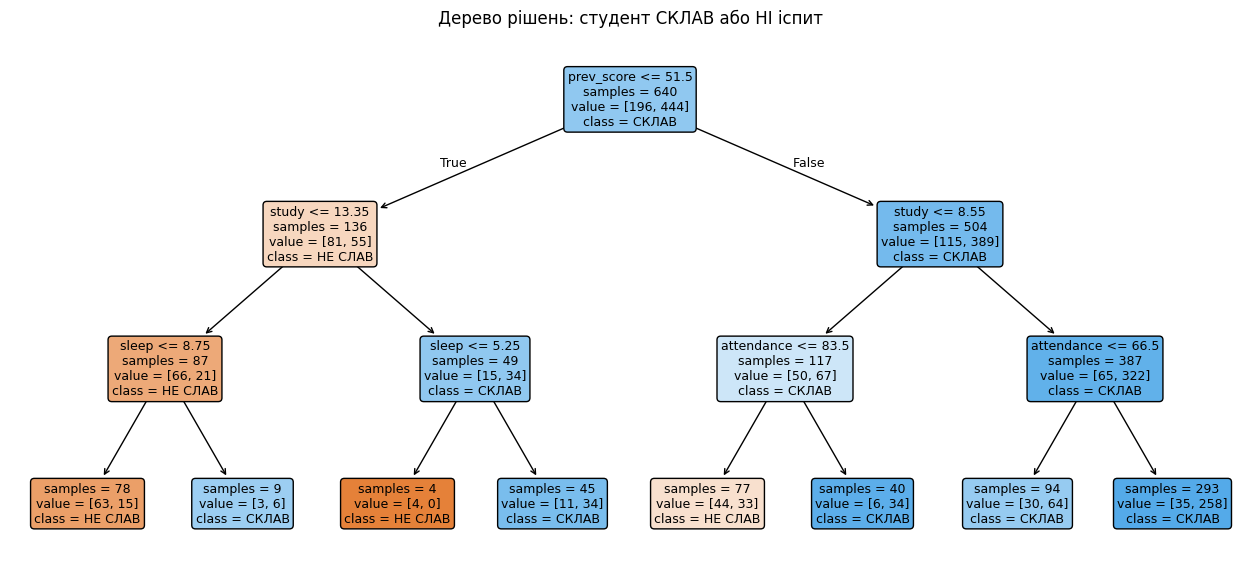

In [119]:
from sklearn.tree import plot_tree

plt.figure(figsize=(16, 7))
plot_tree(
    tree,
    feature_names=Xs.columns,
    class_names=['НЕ СЛАВ', 'СКЛАВ'],
    filled=True, rounded=True, fontsize=9, impurity=False
)

plt.title('Дерево рішень: студент СКЛАВ або НІ іспит')
plt.show()

### Крок B4. Передбач і оціни
- Передбач на `Xs_test`.
- Порахуй **accuracy** і побудуй **матрицю плутанини**.

*Підказка:* `accuracy_score(ys_test, ys_pred)` та `confusion_matrix(ys_test, ys_pred)`.

In [120]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# TODO: передбач ys_pred, порахуй accuracy та матрицю плутанини
ys_pred = tree.predict(Xs_test)

acc = accuracy_score(ys_test, ys_pred)
print(f'Accuracy = {acc:.2%}\n')

cm = confusion_matrix(ys_test, ys_pred)
df_cm = pd.DataFrame(
    cm,
    index=['Насправді НЕ СКЛАВ', 'Насправді СКЛАВ'],
    columns=['Передбачено НЕ СКЛАВ', 'Передбачено СКЛАВ']
)

print('Матриця плутанини:')
display(df_cm)

print('\nДетальний звіт по метриках:')
print(classification_report(ys_test, ys_pred, target_names=['НЕ СКЛАВ', 'СКЛАВ']))

Accuracy = 75.62%

Матриця плутанини:


,Передбачено НЕ СКЛАВ,Передбачено СКЛАВ
Насправді НЕ СКЛАВ,25,24
Насправді СКЛАВ,15,96



Детальний звіт по метриках:
              precision    recall  f1-score   support

    НЕ СКЛАВ       0.62      0.51      0.56        49
       СКЛАВ       0.80      0.86      0.83       111

    accuracy                           0.76       160
   macro avg       0.71      0.69      0.70       160
weighted avg       0.75      0.76      0.75       160



### Крок B5. Що найбільше впливає на результат?
Виведи важливість ознак дерева й назви найважливішу.

*Підказка:* `tree.feature_importances_`, зістав із `Xs.columns`.

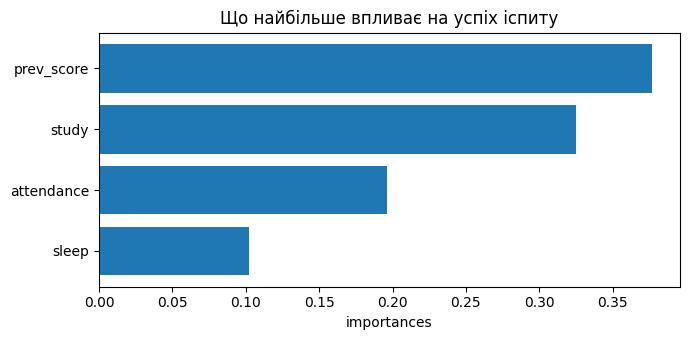

,features,importances
3,sleep,0.102
1,attendance,0.196
0,study,0.325
2,prev_score,0.377


In [121]:
# TODO: таблиця "ознака — важливість", відсортована за спаданням

importances = pd.DataFrame({
    'features': Xs.columns,
    'importances': tree.feature_importances_.round(3)
}).sort_values('importances', ascending=True)

plt.figure(figsize=(7, 3.5))
plt.barh(importances['features'], importances['importances'])

plt.title("Що найбільше впливає на успіх іспиту")
plt.xlabel('importances')

plt.tight_layout()
plt.show()

importances

✍️ **Відповідь словами:**
> Найбільше на складання іспиту впливає prev_score (бал за минулий іспит), оскільки цей показник має найбільшу важливість (0.377) серед усіх ознак у моделі.

### Крок B6. Передбач для нового студента
Студент: навчання 15 год, відвідуваність 85%, минулий бал 70, сон 7.5.
Виведи і рішення (`predict`), і **ймовірність** скласти (`predict_proba`).

*Підказка:* `predict_proba(...)[0, 1]` — це ймовірність класу «склав».

In [122]:
# TODO: створи new_student, виведи рішення та ймовірність

new_student = pd.DataFrame([{
    'study': 15,
    'attendance': 85,
    'prev_score': 70,
    'sleep': 7.5
}])

display(new_student)

print(f'\nЙмовірність, що студент складе іспит: {tree.predict_proba(new_student)[0, 1]:.2%}')
print(f'Рішення: {"СКЛАДЕ" if tree.predict(new_student)[0] else "НЕ СКЛАДЕ"}')

print('\n------------\n')
print(f'Вирогідність результату: {accuracy_score(ys_test, ys_pred):.2%}')

,study,attendance,prev_score,sleep
0,15,85,70,7.5



Ймовірність, що студент складе іспит: 88.05%
Рішення: СКЛАДЕ

------------

Вирогідність результату: 75.62%


---
# ⭐ Бонус (необов'язково, але корисно)

1. **Перевір на перенавчання.** Для дерева зі Задачі B порахуй accuracy окремо на `Xs_train` і на `Xs_test`. Великий розрив = зубріння. Потім спробуй `max_depth=10` — розрив зросте?
2. **Сильніша модель.** Навчи `RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)` на тих самих даних і порівняй accuracy з деревом.
3. **Прибери ознаку.** У Задачі A прибери `experience` з `X`, перенавчи й подивись, як впаде R². Який висновок про важливість стажу?

In [123]:
# Місце для бонусних експериментів

---
# 🧠 Питання на розуміння (без коду)

Дай собі відповідь словами (правильні — у блокноті з розв'язками):
1. Чому ми оцінюємо модель на `X_test`, а не на `X_train`?
2. Задача «передбачити кількість проданих квитків» — це регресія чи класифікація? А «спам / не спам»?
3. Що означає R² = 0.85 простими словами?
4. Чому accuracy може бути оманливою, якщо лише 5% студентів провалюють іспит?
5. Коефіцієнт `english = +1500`. Як прочитати це вголос для керівника?

> 🎯 Якщо впорався із задачами A і B без підглядання — ти впевнено володієш базовим циклом ML. Вітаю!